**Problem 1 (40 pontos)**

Consider the following two AR processes, with zero initial conditions and **w** being white noise with a uniform distribution, zero mean, and variance equal to 2.

$$
(I)\ x(k) = w(k) + 3/2x(k-1) - x(k-2) + 1/4x(k-3)
$$
$$
(II)\ x(k) = w(k) + 3/2x(k-1) - 1/2x(k-2) + 3/4x(k-3)
$$

a) From the characteristic polynomials, draw conclusions about the stability of these systems.

**Process (I)**
$$
x(k) = w(k) + 3/2x(k-1) - x(k-2) + 1/4x(k-3)
$$
$$
w(k) = x(k) - 3/2x(k-1) + x(k-2) - 1/4x(k-3)
$$
$$
C(z) = z^3 - 3/2z^2 + z - 1/4 = 0 \implies z = 0.5 \ and \ z = \frac{1 \pm \sqrt{1-2}}{2} =  \frac{1 \pm i}{2} = 0.5 \pm 0.5i
$$

**Process (II)**
$$
x(k) = w(k) + 3/2x(k-1) - 1/2x(k-2) + 3/4x(k-3)
$$
$$
w(k) = x(k) - 3/2x(k-1) + 1/2x(k-2) - 3/4x(k-3)
$$
$$
C(z) = z^3 - 3/2z^2 + 1/2z - 3/4 = 0 \implies z = 1.5 \ and \ z = \pm i \sqrt{0.5} = \pm0.7071i
$$





b) Study the stability of the same systems using a simulation approach.

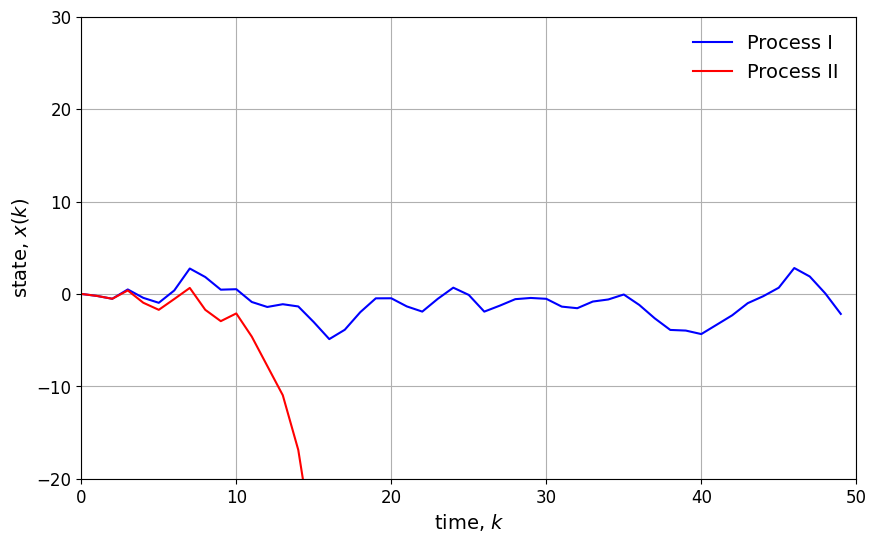

In [8]:
# libraries
import numpy as np
import matplotlib.pyplot as plt

# seed
seed = 7
np.random.seed(seed)

# parameters
h = 1
Z = 50
N = int(Z/h)

t = np.zeros(N)
w = np.zeros(N)
a = np.zeros(N)
b = np.zeros(N)

# AR processes
for k in range(N):
    w[k] = np.sqrt(-2 * np.log(np.random.random_sample()))\
       * np.cos(2 * np.pi * np.random.random_sample())
    if (k >= 3):
        a[k] = w[k] + 3/2 * a[k-1] - a[k-2] + 1/4 * a[k-3]
        b[k] = w[k] + 3/2 * b[k-1] - 1/2 * b[k-2] + 3/4 * b[k-3]
    elif (k >= 2):
        a[k] = w[k] + 3/2 * a[k-1] - a[k-2]
        b[k] = w[k] + 3/2 * b[k-1] - 1/2 * b[k-2]
    elif (k >= 1):
        a[k] = w[k] + 3/2 * a[k-1]
        b[k] = w[k] + 3/2 * b[k-1]
    t[k] = h * k


# Figure
fig = plt.subplots()
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["font.size"] = "12"
plt.grid()
plt.plot(t, a,"b-",label = "Process I")
plt.plot(t, b,"r-",label = "Process II")
plt.xlabel("time, $k$",fontsize=14)
plt.ylabel(r"state, $x(k)$",fontsize=14)
plt.legend(prop={"size":14},frameon=False)
plt.axis([0, 50, -20, 30])
plt.show()

**Comments**

The plot shows that process I (blue line) remain bounded around zero, exhibiting a lightly damped oscillatory behavior. Over time, the fluctuations do not grow, giving the appearance of a stationary AR process. 

In contrast, process II (red line) becomes unstable due to the presence of a real root at 1.5, which is greater than 1. As a consequence, the response grows rapidly in magnitude within 25 samples rather than decaying. Since its characteristic root lies outside the unit circle, the process is classified as unstable

c) Analyze the results and provide the proper comments.

**Process I**

Process I is stationary (stable) because its AR roots are 0.5 and $0.5\pm 0.5i$, whose magnitudes are 0.5 and $\sqrt{0.5}\approx0.7071 < 1$.

The complex pair implies a lightly damped oscillation (angle $\pi/4rad/sample$ $\implies$ period $\approx 8$ samples).


**Process II**

Regarding process II, this process is non-stationary (unstable) because one AR root is 1.5(magnitude $>$ 1), while the other two are $\pm 0.7071i\ (magnitude \approx 0.7071<1)$.

The complex pair would produce a damped oscillation at $\omega=\pi/2rad/sample (period \approx 4 samples)$, but the real pole at 1.5 causes exponential growth and, thus it can not be considered a stable process.


**Problem 2 (60 pontos)**

Model the following autocorrelation data as an AR process of:

| $\tau$ | $R_{xx}(\tau)$ |
| --- |---|
| 0 | 10.7 |
| 1 | 7.0 |
| 2 | 6.5 |
| 3 | 5.5 |
| 4 | 6.0 |
| 5 | 4.0 |
| 6 | 2.0 |
| 7 | 1.0 |

a) First-order;

b) Second-order;

c) Third-order.

For each model, compare the predicted autocorrelation values ​​with the original data. Begin by modeling the process and then create a simulation instance. From the simulation results, calculate the autocorrelation coefficients and variance. Compare them with the original data, and provide the proper comments.